## Carregamento e Visualização

In [ ]:
import datetime
from pathlib import Path
from typing import Literal, Union

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

# ============================================================
# FUNCOES DE CARREGAMENTO E PRE-PROCESSAMENTO
# ============================================================

column_types = Union[
    type[datetime.datetime], type[float], type[int], type[np.float64], type[np.int64]
]


def preprocessamento(
    df: pd.DataFrame, name: str) -> pd.DataFrame:
    """Remove linhas com NaN e valores invalidos e exibe um resumo ordenado."""
    df_info = df.isna().astype(int)
    print("\nMatriz de NaN (1 = NaN, 0 = valor valido):")
    print(df_info)

    nan_por_coluna = (
        df.isna()
        .sum()
        .sort_values(ascending=False)
        .to_frame(name="quantidade_nan")
    )

    dtypes_coluna = [col for col in df.dtypes]
    print(dtypes_coluna)
    print("\nQuantidade de NaN por coluna (ordem decrescente):")
    nan_por_coluna.to_csv("info_m4.csv")

    df_clean = df.dropna().copy()
    total_removido = len(df) - len(df_clean)
    percentual_removido = (total_removido / len(df) * 100) if len(df) else 0
    print(f"\n{total_removido} linhas removidas ({percentual_removido:.2f}%).")

    print(df_clean.dtypes)

    return df_clean

# Helpers para salvar e ler Parquet sem especificar engine (deixa o pandas escolher automaticamente)
def save_parquet(df: pd.DataFrame, path: Path, compression: str = "gzip") -> None:
    """Salva usando fastparquet para evitar conflitos de registro do pyarrow."""
    try:
        # Tenta usar fastparquet primeiro
        df.to_parquet(path, compression=compression, engine="pyarrow", index=True)
        print(f"Dataset salvo com sucesso em: {path}")
    except Exception as e:
        print(f"Falha ao salvar com pyarrow: {e}")
        # Fallback para pyarrow
        raise

def load_parquet(path: Path) -> pd.DataFrame:
    """Carrega DataFrame de Parquet usando pyarrow."""
    try:
        return pd.read_parquet(path, engine="pyarrow")
    except Exception as e:
        print(f"Falha ao ler parquet {path}: {e}")
        raise

def filtrar_dataset(df: pd.DataFrame) -> pd.DataFrame:
    """Filtra colunas específicas e remove linhas vazias."""
    # Filtrar colunas V1 a V100
    df = df.loc[:, "V1":"V100"]
    # Remover linhas onde todos os valores são NaN
    original_len = len(df)
    df = df.dropna(how='all')
    
    removidas = original_len - len(df)
    print(f"Linhas removidas pelo dropna: {removidas} ({ (removidas/original_len)*100:.2f}%)")
    return df


# ============================================================
# EXECUCAO PRINCIPAL
# ============================================================
# Aplicar dropna e mostrar porcentagem removida
print("\n" + "=" * 60)
print("PRÉ-PROCESSAMENTO:\n\n")
print("ANALISE DE VALORES FALTANTES (dropna)")
print("=" * 60)
PATH_FONTE_DADOS = Path("data")

file_path = PATH_FONTE_DADOS / "daily-train.csv"  # PEGADO DE https://www.kaggle.com/datasets/ehsankhani/fixed-nn5-dataset
file_parquet = Path("dataset.parquet")

if file_parquet.exists():
    print(f"Lendo dataset a partir de Parquet: {file_parquet}")
    dataset = load_parquet(file_parquet)
else:
    print(f"Parquet nao encontrado, salvando em: {file_parquet}")
    dataset: pd.DataFrame = pd.read_csv(file_path, header="infer", index_col=0)
    print(dataset.dtypes)
    save_parquet(dataset, file_parquet)


CONFIG = yaml.load("config.yaml")
treinar = bool(CONFIG["train"])
if not treinar:
    dataset = filtrar_dataset(dataset)

name = "M4"
dataset = preprocessamento(dataset, name.upper())
dataset.to_csv("dataset_clean.csv")
# Mostrar estatisticas descritivas
dataset.describe(include="all")

# Preparar dados para analise anual
print("\n" + "=" * 60)
print("PREPARANDO DADOS PARA ANALISE ANUAL")
print("=" * 60)

print(f"NAME: {name}")
print(dataset.head(5))


PRÉ-PROCESSAMENTO:


ANALISE DE VALORES FALTANTES (dropna)
Lendo dataset a partir de Parquet: dataset.parquet
config.yaml


TypeError: string indices must be integers, not 'str'

## Erros com dias vazios: Optando por agregar valores por semana, mas manter index de data

In [16]:
def agregacao_semanal(df: pd.DataFrame) -> pd.DataFrame:
    """Agrega um DataFrame temporal para frequencia semanal mantendo indice Date."""
    df_week = df.copy()

    if "Date" in df_week.columns:
        df_week["Date"] = pd.to_datetime(
            df_week["Date"], errors="coerce", dayfirst=True
        )
        df_week = df_week.dropna(subset=["Date"]).set_index("Date")

    if not isinstance(df_week.index, pd.DatetimeIndex):
        converted = pd.to_datetime(df_week.index, errors="coerce")
        df_week = df_week.loc[converted.notna()].copy()
        df_week.index = converted[converted.notna()]

    df_week = df_week.sort_index()

    # Agrega valores numericos por semana
    weekly = df_week.resample("W").mean(numeric_only=True)

    # Mantem um indice semanal regular entre min e max
    weekly_index = pd.date_range(
        start=weekly.index.min(), end=weekly.index.max(), freq="W"
    )
    weekly = weekly.reindex(weekly_index)
    weekly.index.name = "Date"

    return weekly


dataset = agregacao_semanal(dataset)
print(dataset.head(), len(dataset))

            Cotação USD-BRL
Date                       
2006-04-16          2.13540
2006-04-23          2.14260
2006-04-30          2.12535
2006-05-07          2.11334
2006-05-14          2.06695 1045


## Plotando série temporal e histograma


PLOTANDO SERIES TEMPORAIS


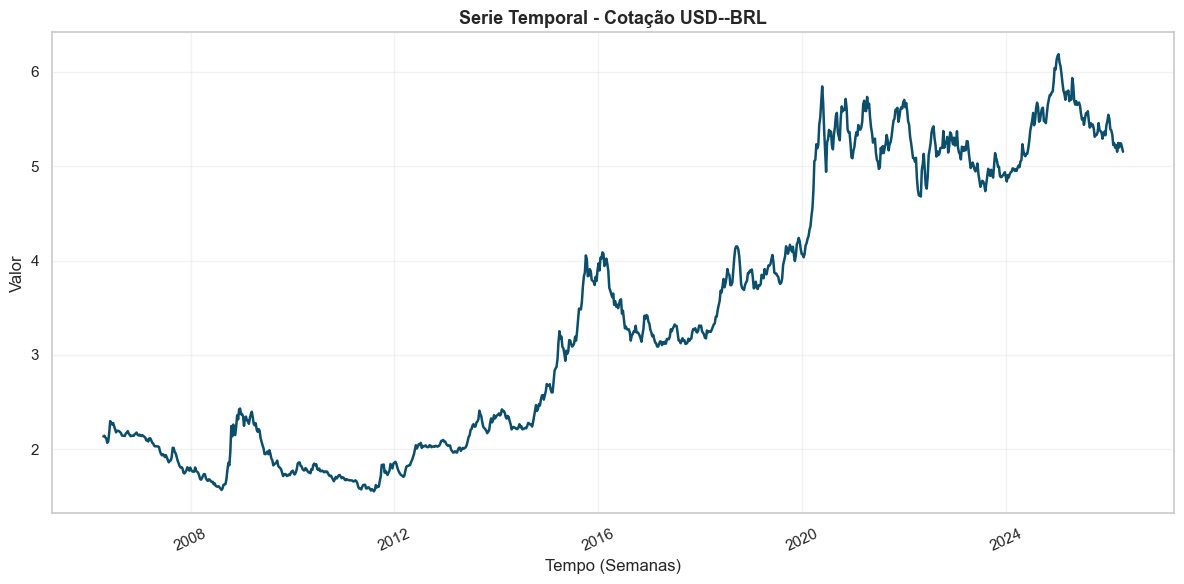


PLOTANDO HISTOGRAMAS


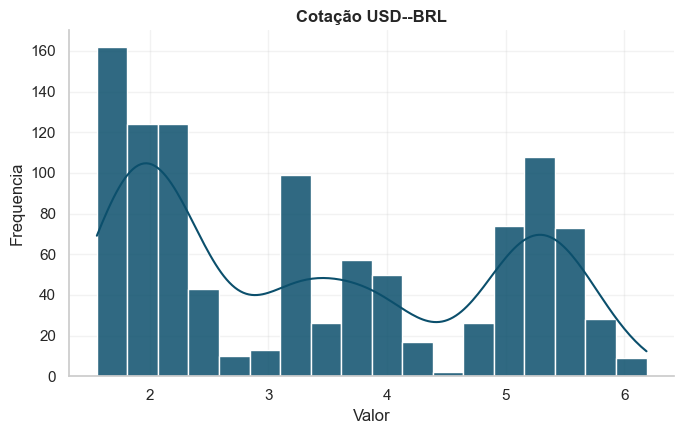


PLOTANDO TABELA DE RESUMO ESTATISTICO


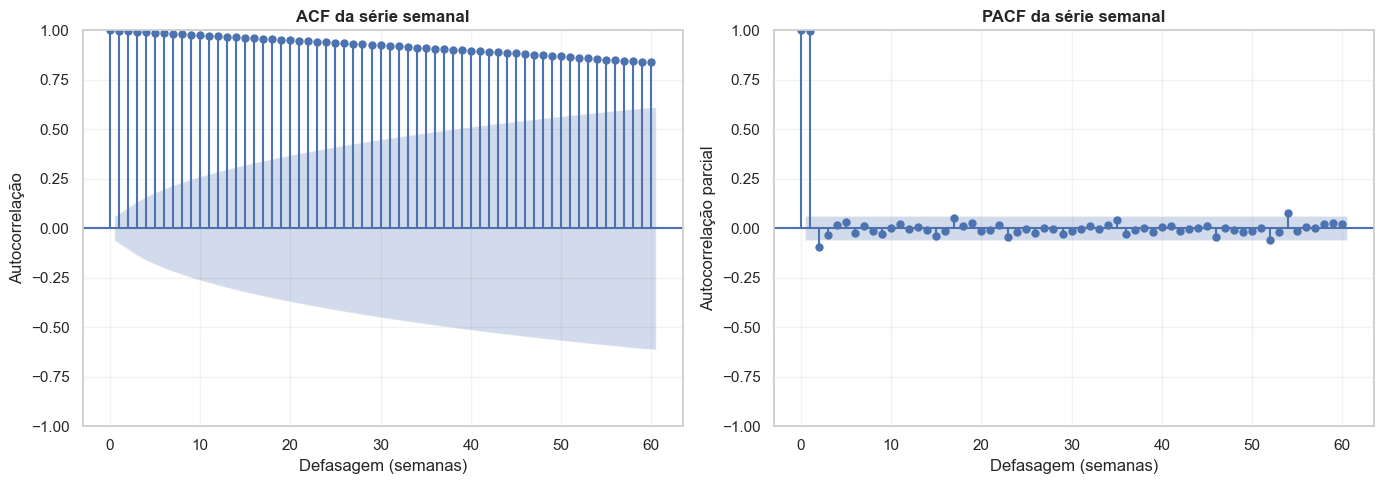

In [ ]:
from typing import Dict, List, Optional

import numpy as np
import pandas as pd
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


# ============================================================
# FUNCOES DE VISUALIZACAO
# ============================================================

def _prepare_for_time_plot(df: pd.DataFrame) -> pd.DataFrame:
    """Prepara DataFrame para plot temporal usando Date/Ano quando disponivel."""
    plot_df = df.copy()

    if "Date" in plot_df.columns:
        plot_df["Date"] = pd.to_datetime(plot_df["Date"], errors="coerce", dayfirst=True)
        plot_df = plot_df.dropna(subset=["Date"]).set_index("Date")
    elif "Ano" in plot_df.columns:
        ano = pd.to_numeric(plot_df["Ano"], errors="coerce")
        plot_df = plot_df.loc[ano.notna()].copy()
        plot_df["Ano"] = ano.loc[ano.notna()].astype(int).astype(str)
        plot_df = plot_df.set_index(pd.to_datetime(plot_df["Ano"], format="%Y", errors="coerce"))
        plot_df = plot_df.drop(columns=["Ano"], errors="ignore")

    if isinstance(plot_df.index, pd.PeriodIndex):
        plot_df.index = plot_df.index.to_timestamp()
    elif not isinstance(plot_df.index, pd.DatetimeIndex):
        converted_index = pd.to_datetime(plot_df.index, errors="coerce")
        valid_mask = np.asarray(converted_index.notna(), dtype=bool)
        if int(valid_mask.sum()) > 0:
            plot_df = plot_df.loc[valid_mask].copy()
            plot_df.index = converted_index[valid_mask]

    numeric_df = plot_df.select_dtypes(include=[np.number]).copy()
    return numeric_df.sort_index()


def plot_time_series(
    df: pd.DataFrame,
    title: str = "Serie Temporal",
    colors: Optional[List[str]] = None,
) -> None:
    """Plota serie temporal de um unico DataFrame com estilo Seaborn."""
    default_colors: List[str] = ["tab:blue", "tab:orange", "tab:green"]
    plot_df = _prepare_for_time_plot(df)

    if plot_df.empty:
        _, ax = plt.subplots(figsize=(12, 6))
        ax.set_title(f"{title} (sem colunas numericas)")
        ax.grid(True, alpha=0.25)
        plt.tight_layout()
        plt.show()
        return

    long_df = plot_df.reset_index().melt(
        id_vars=[plot_df.index.name or "index"],
        var_name="Serie",
        value_name="Valor",
    )
    tempo_col = long_df.columns[0]
    long_df = long_df.rename(columns={tempo_col: "Tempo"})

    fig, ax = plt.subplots(figsize=(12, 6))

    if plot_df.shape[1] == 1:
        color = colors[0] if colors and len(colors) > 0 else default_colors[0]
        sns.lineplot(
            data=long_df,
            x="Tempo",
            y="Valor",
            linewidth=1.8,
            color=color,
            ax=ax,
        )
    else:
        palette = colors if colors else default_colors
        sns.lineplot(
            data=long_df,
            x="Tempo",
            y="Valor",
            hue="Serie",
            linewidth=2.0,
            palette=palette,
            ax=ax,
        )

    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Tempo (Semanas)")
    ax.set_ylabel("Valor")
    ax.tick_params(axis="x", rotation=25)
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()
    plt.close(fig)


def plot_histograms(
    df: pd.DataFrame,
    title: str = "Histograma",
    color: str = "tab:blue",
) -> None:
    """Plota histograma de um unico DataFrame com estilo Seaborn."""
    numeric_df = df.select_dtypes(include=[np.number]).copy()

    _, ax = plt.subplots(figsize=(7, 4.5))

    if numeric_df.empty:
        ax.set_title(f"{title} (sem valores numericos)", fontsize=12, fontweight="bold")
        ax.grid(True, alpha=0.25)
        plt.tight_layout()
        plt.show()
        return

    values = numeric_df.to_numpy(dtype=float).ravel()
    values = values[~np.isnan(values)]
    sns.histplot(values, bins=18, kde=True, color=color, edgecolor="white", alpha=0.85, ax=ax)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Valor")
    ax.set_ylabel("Frequencia")
    ax.grid(True, alpha=0.25)
    sns.despine(ax=ax)
    plt.tight_layout()
    plt.show()


def plot_summary_tables(
    df: pd.DataFrame,
    dataset_name: str = "dataset",
) -> None:
    """Plota tabela com estatisticas separadas por serie temporal de um unico DataFrame."""
    numeric_df = df.select_dtypes(include=[np.number])
    stats_rows: List[Dict[str, object]] = []

    if numeric_df.empty:
        stats_rows.append(
            {
                "Dataset": dataset_name,
                "Serie": "sem dados numericos",
                "Observacoes": 0,
                "Media": np.nan,
                "Minimo": np.nan,
                "Maximo": np.nan,
                "Desvio padrao": np.nan,
            }
        )
    elif isinstance(numeric_df.index, pd.MultiIndex) and numeric_df.index.nlevels > 1:
        first_numeric_col = numeric_df.columns[0]
        wide_df = numeric_df[first_numeric_col].unstack(level=1)
        for col in wide_df.columns:
            serie_vals = wide_df[col].dropna()
            if serie_vals.empty:
                obs = 0
                media = minimo = maximo = desvio = np.nan
            else:
                obs = int(serie_vals.count())
                media = float(serie_vals.mean())
                minimo = float(serie_vals.min())
                maximo = float(serie_vals.max())
                desvio = float(serie_vals.std())
            stats_rows.append(
                {
                    "Dataset": dataset_name,
                    "Serie": str(col),
                    "Observacoes": obs,
                    "Media": media,
                    "Minimo": minimo,
                    "Maximo": maximo,
                    "Desvio padrao": desvio,
                }
            )
    else:
        for col in numeric_df.columns:
            serie_vals = numeric_df[col].dropna()
            if serie_vals.empty:
                obs = 0
                media = minimo = maximo = desvio = np.nan
            else:
                obs = int(serie_vals.count())
                media = float(serie_vals.mean())
                minimo = float(serie_vals.min())
                maximo = float(serie_vals.max())
                desvio = float(serie_vals.std())
            stats_rows.append(
                {
                    "Dataset": dataset_name,
                    "Serie": str(col),
                    "Observacoes": obs,
                    "Media": media,
                    "Minimo": minimo,
                    "Maximo": maximo,
                    "Desvio padrao": desvio,
                }
            )

    stats_df = pd.DataFrame(stats_rows)
    display_df = stats_df.copy()

    for col in ["Media", "Minimo", "Maximo", "Desvio padrao"]:
        display_df[col] = display_df[col].map(lambda x: f"{x:.2f}" if pd.notna(x) else "NaN")

    _, ax = plt.subplots(figsize=(12, 0.9 * len(display_df) + 1.8))
    ax.axis("off")

    table = ax.table(
        cellText=display_df.values.tolist(),
        colLabels=display_df.columns.tolist(),
        cellLoc="center",
        loc="center",
    )

    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.6)

    for (row, _), cell in table.get_celld().items():
        if row == 0:
            cell.set_text_props(weight="bold")
            cell.set_facecolor("#D6EAF8")

    ax.set_title("Resumo Estatistico por Serie Temporal", fontsize=13, fontweight="bold", pad=14)
    plt.tight_layout()
    plt.show()


print("\n" + "=" * 60)
print("PLOTANDO SERIES TEMPORAIS")
print("=" * 60)
plot_time_series(
    dataset,
    title="Serie Temporal - Cotação USD--BRL",
    colors=["#0B4F6C", "#D1495B", "#2A9D8F"],
)

# Plotar histogramas
print("\n" + "=" * 60)
print("PLOTANDO HISTOGRAMAS")
print("=" * 60)
plot_histograms(
    dataset,
    title="Cotação USD--BRL",
    color="#0B4F6C",
)

# Plotar tabela com estatisticas resumo
print("\n" + "=" * 60)
print("PLOTANDO TABELA DE RESUMO ESTATISTICO")
print("=" * 60)
# plot_summary_tables(dataset, dataset_name="dolar")


# Série semanal (usa a primeira coluna numérica do dataset)
serie_semanal = dataset.select_dtypes(include=[np.number]).iloc[:, 0].dropna()

# Definir max_lags com base no tamanho da série
max_lags = min(60, max(1, len(serie_semanal) // 2 - 1))
lags_acf = max_lags
lags_pacf = min(max_lags, (len(serie_semanal) // 2) - 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(serie_semanal, lags=lags_acf, ax=axes[0], alpha=0.05)
axes[0].set_title("ACF da série semanal", fontweight="bold")
axes[0].set_xlabel("Defasagem (semanas)")
axes[0].set_ylabel("Autocorrelação")
axes[0].grid(True, alpha=0.25)

plot_pacf(serie_semanal, lags=lags_pacf, ax=axes[1], alpha=0.05, method="ywm")
axes[1].set_title("PACF da série semanal", fontweight="bold")
axes[1].set_xlabel("Defasagem (semanas)")
axes[1].set_ylabel("Autocorrelação parcial")
axes[1].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

## Análise da série

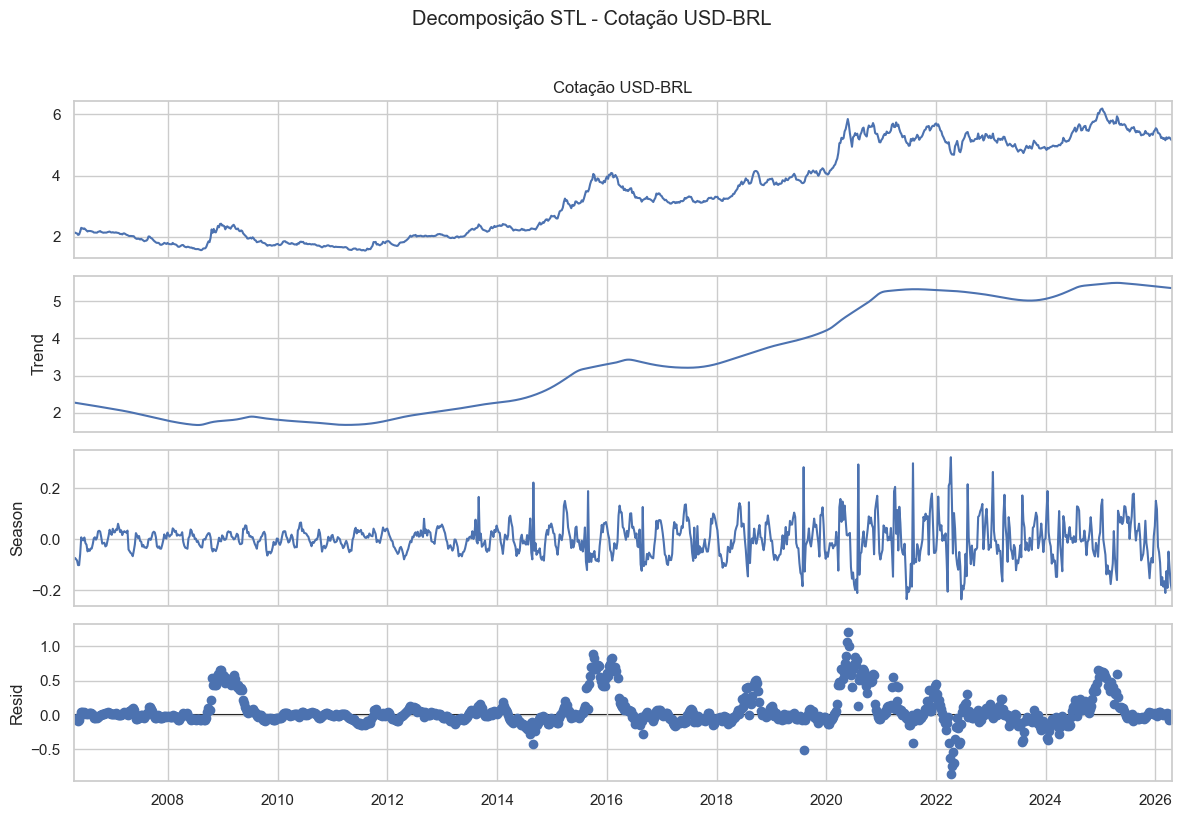

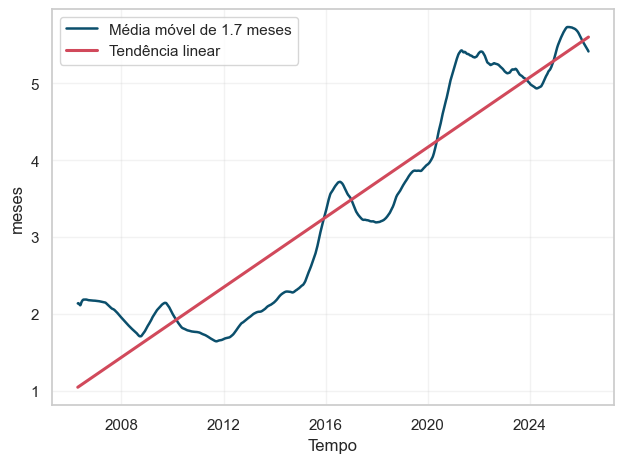

In [ ]:
from pandas import PeriodIndex
import pandas as pd
from sklearn.linear_model import LinearRegression
import numpy as np
from statsmodels.tsa.seasonal import STL

def calc_stats(df):
    window = int(360/7) #indice esta em dias, logo isso da 1/7 ano
    # pd.Series(list(df.rolling(window)))
    tend = df.iloc[:, 0].astype(float).rolling(window=window, min_periods=1).mean()

    period_idx: PeriodIndex = PeriodIndex(dolar_df.index, freq="D")
    tend.index = period_idx.to_timestamp()

    if window//360 < 1:
        window = round(window/30, 1)
        label = "meses"
    else:
        window = window//360
        label = "anos"

    fig, ax = plt.subplots(1,1)
    ax.set_xlabel("Ano")
    ax.set_ylabel("USD-BRL (em Reais)")
    ax.grid(True, alpha=0.3)

    x = tend.index.map(pd.Timestamp.toordinal).to_numpy(dtype=float).reshape(-1, 1)
    y = tend.to_numpy(dtype=float)

    model = LinearRegression()
    model.fit(x, y)

    y_pred = model.predict(x)

    sns.lineplot(x=tend.index, y=tend, ax=ax, label=f"Média móvel de {window} {label}", color="#0B4F6C", linewidth=1.8)
    sns.lineplot(x=tend.index, y=y_pred, ax=ax, label="Tendência linear", color="#D1495B", linewidth=2.2)

    sns.set_theme(style="whitegrid")

    ax.set_xlabel("Tempo")
    ax.set_ylabel(label)
    ax.grid(True, alpha=0.25)
    ax.legend(loc="best")

    plt.tight_layout()
    plt.show()
    plt.close(fig)


def plot_regressao_linear_intervalo_total(
    df: pd.DataFrame,
    value_col: str = "Cotação USD-BRL"
 ) :
    """Plota a serie e a regressao linear usando todo o intervalo temporal."""
    work_df = df.copy()

    if value_col not in work_df.columns:
        numeric_cols = work_df.select_dtypes(include=[np.number]).columns.tolist()
        if not numeric_cols:
            raise ValueError("Nao existem colunas numericas para regressao linear.")
        value_col = numeric_cols[0]

    series = pd.to_numeric(work_df[value_col], errors="coerce").dropna()
    if series.empty:
        raise ValueError("Serie vazia apos limpeza; nao foi possivel ajustar regressao.")
    x = series.index.map(pd.Timestamp.toordinal).to_numpy(dtype=float).reshape(-1, 1)
    y = series.to_numpy(dtype=float)

    model = LinearRegression()
    model.fit(x, y)

    y_pred = model.predict(x)

    sns.set_theme(style="whitegrid")
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.lineplot(x=series.index, y=y, ax=ax, label="Serie observada", color="#0B4F6C", linewidth=1.8)
    sns.lineplot(x=series.index, y=y_pred, ax=ax, label="Regressao linear", color="#D1495B", linewidth=2.2)

    ax.set_title("Linha de tendência do intervalo total", fontsize=13, fontweight="bold")
    ax.set_xlabel("Tempo")
    ax.set_ylabel(value_col)
    ax.grid(True, alpha=0.25)
    ax.legend(loc="best")

    plt.tight_layout()
    plt.show()
    plt.close(fig)

    return model

dolar_df: pd.DataFrame = dataset

# Série numérica correta (em vez de lista de arrays)
dolar_series: pd.Series = pd.to_numeric(dolar_df.iloc[:, 0], errors="coerce").dropna()
dolar_series.index = pd.to_datetime(dolar_df.index)
dolar_series = dolar_series.sort_index()

def sazon(df: pd.DataFrame):
    serie = pd.to_numeric(df.iloc[:, 0], errors="coerce").dropna()
    serie.index = pd.to_datetime(df.index)
    serie = serie.sort_index()

    # Converter para DatetimeIndex se necessário para infer_freq
    if not isinstance(serie.index, pd.DatetimeIndex):
        serie.index = pd.DatetimeIndex(serie.index)

    freq = pd.infer_freq(serie.index)
    if freq and "W" in freq:
        period = 52
    elif freq and "M" in freq:
        period = 12
    else:
        period = 365

    stl = STL(serie, period=period, robust=True)
    resultado_stl = stl.fit()

    fig = resultado_stl.plot()
    fig.set_size_inches(12, 8)
    fig.suptitle("Decomposição STL - Cotação USD-BRL", y=1.02)
    plt.tight_layout()
    plt.show()

    return resultado_stl

def estacionaria(df: pd.DataFrame) -> pd.Series:
    resultado_stl = sazon(df)
    # Resíduo da STL costuma ser a parte mais próxima de estacionária
    return resultado_stl.resid.dropna()

# Plota componentes STL (observado, tendência, sazonalidade e resíduo)
resultado_stl = sazon(dolar_df)


calc_stats(dolar_df)
# tendencia = plot_regressao_linear_intervalo_total(dataset)

## Dickey-Fuller

In [5]:
from typing import cast

from statsmodels.tsa.stattools import adfuller

# Seleciona a série numérica principal
col = dolar_df.select_dtypes(include=[np.number]).columns[0]
serie = pd.to_numeric(dolar_df[col], errors="coerce").dropna()

# Teste Dickey-Fuller aumentado (ADF)
ADFResult = tuple[float, float, int, int, dict[str, float], float]
resultado_adf = cast(ADFResult, adfuller(serie, autolag="AIC"))

print("=== Teste Dickey-Fuller (ADF) ===")
print(f"Série: {col}")
print(f"Estatística ADF: {resultado_adf[0]:.6f}")
print(f"p-valor: {resultado_adf[1]:.6f}")
print(f"Lags usados: {resultado_adf[2]}")
print(f"Nº de observações: {resultado_adf[3]}")
print("Valores críticos:")
for k, v in resultado_adf[4].items():
    print(f"  {k}: {v:.6f}")

alpha = 0.05
if resultado_adf[1] < alpha:
    print("A série é estacionária.")
else:
    print("A série NÃO É estacionária.")

=== Teste Dickey-Fuller (ADF) ===
Série: Cotação USD-BRL
Estatística ADF: -0.591357
p-valor: 0.872923
Lags usados: 4
Nº de observações: 1040
Valores críticos:
  1%: -3.436653
  5%: -2.864323
  10%: -2.568252
A série NÃO É estacionária.


=== Série transformada por diferenciação de ordem 1 ===
Série: Cotação USD-BRL
Estatística ADF: -16.602000
p-valor: 0.000000
Lags usados: 3
Nº de observações: 1040
Valores críticos:
  1%: -3.436653
  5%: -2.864323
  10%: -2.568252

Conclusão: série transformada é estacionária.


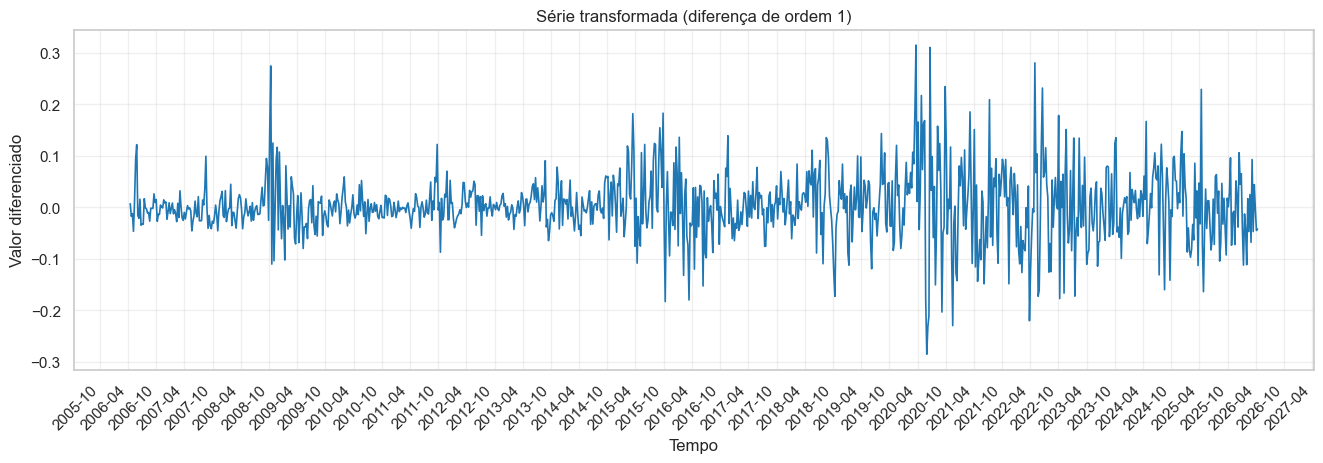

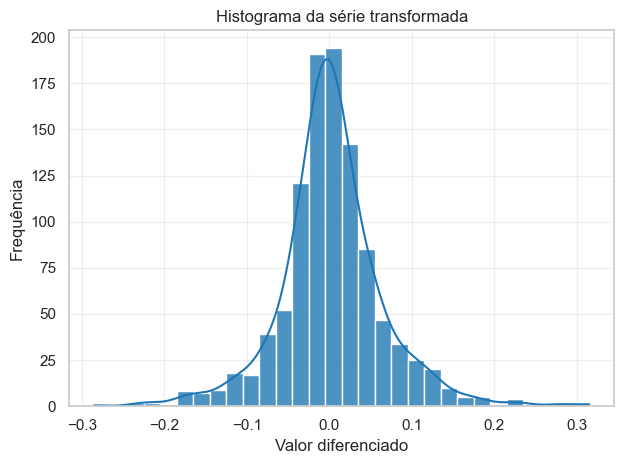

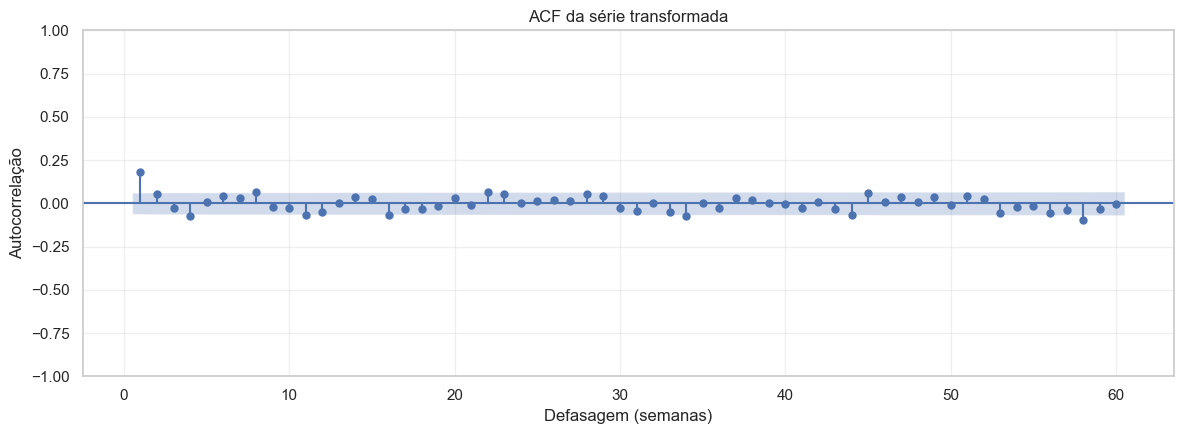

In [17]:
from typing import cast

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf

# Série numérica base
col = dolar_df.select_dtypes(include=[np.number]).columns[0]
serie_base = pd.to_numeric(dolar_df[col], errors="coerce").dropna()

alpha = 0.05
ordem_escolhida = None
serie_transformada = None
resultado_adf_transformada = None

ADFResult = tuple[float, float, int, int, dict[str, float], float]

# Tenta diferenciação de ordem 1 e, se necessário, ordem 2
for ordem in [1, 2]:
    serie_diff = serie_base.diff(ordem).dropna()
    resultado = cast(ADFResult, adfuller(serie_diff, autolag="AIC"))

    if resultado[1] < alpha:
        ordem_escolhida = ordem
        serie_transformada = serie_diff
        resultado_adf_transformada = resultado
        break

# Caso não fique estacionária nem com ordem 2, mantém ordem 2 para relatório
if serie_transformada is None:
    ordem_escolhida = 2
    serie_transformada = serie_base.diff(2).dropna()
    resultado_adf_transformada = cast(ADFResult, adfuller(serie_transformada, autolag="AIC"))

assert serie_transformada is not None
assert resultado_adf_transformada is not None

print(f"=== Série transformada por diferenciação de ordem {ordem_escolhida} ===")
print(f"Série: {col}")
print(f"Estatística ADF: {resultado_adf_transformada[0]:.6f}")
print(f"p-valor: {resultado_adf_transformada[1]:.6f}")
print(f"Lags usados: {resultado_adf_transformada[2]}")
print(f"Nº de observações: {resultado_adf_transformada[3]}")
print("Valores críticos:")
for k, v in resultado_adf_transformada[4].items():
    print(f"  {k}: {v:.6f}")

if resultado_adf_transformada[1] < alpha:
    print("\nConclusão: série transformada é estacionária.")
else:
    print("\nConclusão: a série transformada não é estacionária nas transformações de ordem 1 e 2.")

import matplotlib.dates as mdates

x_vals = pd.to_datetime(serie_transformada.index, errors="coerce")
y_vals = pd.to_numeric(serie_transformada, errors="coerce").to_numpy(dtype=float)

fig, ax1 = plt.subplots(1, 1, figsize=(16, 5))

# Série temporal transformada
ax1.plot(x_vals.to_pydatetime(), y_vals, color="tab:blue", linewidth=1.2)
ax1.set_title(f"Série transformada (diferença de ordem {ordem_escolhida})")
ax1.set_xlabel("Tempo")
ax1.set_ylabel("Valor diferenciado")
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax1.grid(alpha=0.3)
fig.autofmt_xdate(rotation=45)
plt.show()
plt.close()

fig, ax2 = plt.subplots(1)

# Histograma da série transformada
y_hist = y_vals[~np.isnan(y_vals)]
sns.histplot(y_hist, bins=30, kde=True, color="tab:blue", alpha=0.8, edgecolor="white")
ax2.set_title("Histograma da série transformada")
ax2.set_xlabel("Valor diferenciado")
ax2.set_ylabel("Frequência")
ax2.grid(alpha=0.3)


plt.tight_layout()
plt.show()


serie_acf = pd.to_numeric(serie_transformada, errors="coerce").dropna()
max_lags = min(60, max(1, len(serie_acf) // 2 - 1))

fig, ax = plt.subplots(figsize=(12, 4.5))
plot_acf(serie_acf, lags=max_lags, ax=ax, alpha=0.05, zero=False)
ax.set_title("ACF da série transformada")
ax.set_xlabel("Defasagem (semanas)")
ax.set_ylabel("Autocorrelação")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
plt.close(fig)

## Veredito Final
A série não era estacionária, possui tendência de alta, não possui ciclo bem-definido, e ainda está com aumento de instabilidade nos anos recentes, evidenciado pela instabilidade na série de diferenciação de ordem 1.

In [ ]:
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd


def _to_float(value):
    try:
        if value is None:
            return np.nan
        return float(value)
    except Exception:
        return np.nan


def gerar_relatorio_markdown_e_exportar(
    df: pd.DataFrame,
    adf_original=None,
    adf_transformada=None,
    ordem_diff=None,
    formato_saida: str = "md",  # "md", "docx" ou "pdf"
) -> None:
    """Gera relatorio em .md e tenta exportar para .docx/.pdf se disponivel."""
    formato_saida = formato_saida.lower().strip()
    if formato_saida not in {"md", "docx", "pdf"}:
        raise ValueError("formato_saida deve ser 'md', 'docx' ou 'pdf'.")

    reports_dir = Path("reports")
    reports_dir.mkdir(exist_ok=True)

    stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    md_path = reports_dir / f"relatorio_series_temporais_{stamp}.md"
    out_path = reports_dir / f"relatorio_series_temporais_{stamp}.{formato_saida}"

    numeric_df = df.select_dtypes(include=[np.number]).copy()
    col_principal = numeric_df.columns[0] if not numeric_df.empty else "(sem coluna numerica)"

    n_total = int(len(df))
    n_validos = int(numeric_df[col_principal].dropna().shape[0]) if not numeric_df.empty else 0
    inicio = str(df.index.min()) if len(df.index) > 0 else "N/A"
    fim = str(df.index.max()) if len(df.index) > 0 else "N/A"

    media = _to_float(numeric_df[col_principal].mean()) if not numeric_df.empty else np.nan
    minimo = _to_float(numeric_df[col_principal].min()) if not numeric_df.empty else np.nan
    maximo = _to_float(numeric_df[col_principal].max()) if not numeric_df.empty else np.nan
    desvio = _to_float(numeric_df[col_principal].std()) if not numeric_df.empty else np.nan

    p_original = _to_float(adf_original[1]) if adf_original is not None else np.nan
    p_transformada = _to_float(adf_transformada[1]) if adf_transformada is not None else np.nan

    estacionaria_original = "sim" if not np.isnan(p_original) and p_original < 0.05 else "nao"
    estacionaria_transformada = (
        "sim" if not np.isnan(p_transformada) and p_transformada < 0.05 else "nao"
    )

    discussao = [
        "A serie apresenta comportamento nao estacionario na forma original, o que e compativel com a presenca de tendencia no periodo analisado.",
        f"A diferenciacao de ordem {ordem_diff if ordem_diff is not None else 'N/A'} foi utilizada para reduzir componentes de tendencia e variancia de baixa frequencia.",
        "Apos a transformacao, o teste ADF indica melhora na estacionariedade, viabilizando o uso de modelos que assumem media e variancia mais estaveis ao longo do tempo.",
        "Mesmo com a transformacao, periodos recentes sugerem maior volatilidade relativa, o que deve ser considerado na etapa de modelagem e previsao.",
    ]

    md_lines = [
        "# Relatorio de Resultados - Serie Temporal USD-BRL",
        "",
        f"Gerado em: {datetime.now().strftime('%d/%m/%Y %H:%M:%S')}",
        "",
        "## 1) Resumo dos dados",
        f"- Intervalo temporal analisado: **{inicio}** ate **{fim}**",
        f"- Total de observacoes: **{n_total}**",
        f"- Observacoes validas da serie principal ({col_principal}): **{n_validos}**",
        "",
        "## 2) Estatisticas descritivas (serie principal)",
        f"- Media: **{media:.4f}**" if not np.isnan(media) else "- Media: **N/A**",
        f"- Minimo: **{minimo:.4f}**" if not np.isnan(minimo) else "- Minimo: **N/A**",
        f"- Maximo: **{maximo:.4f}**" if not np.isnan(maximo) else "- Maximo: **N/A**",
        f"- Desvio padrao: **{desvio:.4f}**" if not np.isnan(desvio) else "- Desvio padrao: **N/A**",
        "",
        "## 3) Teste de estacionariedade (ADF)",
        f"- p-valor da serie original: **{p_original:.6f}**" if not np.isnan(p_original) else "- p-valor da serie original: **N/A**",
        f"- Serie original estacionaria (alpha=0.05): **{estacionaria_original}**",
        f"- Ordem de diferenciacao adotada: **{ordem_diff if ordem_diff is not None else 'N/A'}**",
        f"- p-valor da serie transformada: **{p_transformada:.6f}**" if not np.isnan(p_transformada) else "- p-valor da serie transformada: **N/A**",
        f"- Serie transformada estacionaria (alpha=0.05): **{estacionaria_transformada}**",
        "",
        "## 4) Discussao breve dos resultados",
    ]

    for item in discussao:
        md_lines.append(f"- {item}")

    md_content = "\n".join(md_lines) + "\n"
    md_path.write_text(md_content, encoding="utf-8")
    print(f"Arquivo markdown gerado em: {md_path}")

    # Tentar converter para o formato solicitado se não for md
    if formato_saida != "md":
        try:
            import pypandoc
            pypandoc.convert_file(str(md_path), formato_saida, outputfile=str(out_path))
            print(f"Arquivo {formato_saida.upper()} gerado em: {out_path}")
        except ImportError:
            print(f"pypandoc nao esta instalado. O arquivo .md foi gerado com sucesso.")
            print(f"Para converter para {formato_saida.upper()}, instale pypandoc: pip install pypandoc")
        except Exception as exc:
            print(f"Erro ao converter para {formato_saida.upper()}: {exc}")
            print("O arquivo .md foi gerado com sucesso.")


# Usa os objetos criados nas celulas anteriores, quando disponiveis.
gerar_relatorio_markdown_e_exportar(
    df=dataset,
    adf_original=globals().get("resultado_adf"),
    adf_transformada=globals().get("resultado_adf_transformada"),
    ordem_diff=globals().get("ordem_escolhida"),
    formato_saida="md",  # Use "md" por padrao para evitar dependencia de pypandoc
)

Arquivo markdown gerado em: reports\relatorio_series_temporais_20260409_211300.md
Nao foi possivel converter automaticamente para PDF. Motivo: No pandoc was found: either install pandoc and add it
to your PATH or or call pypandoc.download_pandoc(...) or
install pypandoc wheels with included pandoc.
O arquivo .md foi gerado com sucesso e pode ser convertido depois via Pandoc.


In [ ]:
import base64
import json
from pathlib import Path


def exportar_figuras_do_notebook_para_imagens(
    notebook_path: str = "main.ipynb",
    output_dir: str = "imagens",
) -> None:
    """Extrai todos os outputs image/png do notebook e salva como arquivos .png."""
    nb_path = Path(notebook_path)
    if not nb_path.exists():
        raise FileNotFoundError(f"Notebook nao encontrado: {nb_path}")

    out_dir = Path(output_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    with nb_path.open("r", encoding="utf-8") as f:
        nb_json = json.load(f)

    cells = nb_json.get("cells", [])
    total_salvas = 0

    for idx_cell, cell in enumerate(cells, start=1):
        if cell.get("cell_type") != "code":
            continue

        outputs = cell.get("outputs", [])
        for idx_output, output in enumerate(outputs, start=1):
            data = output.get("data", {}) if isinstance(output, dict) else {}
            png_data = data.get("image/png")
            if not png_data:
                continue

            if isinstance(png_data, list):
                png_b64 = "".join(png_data)
            else:
                png_b64 = str(png_data)

            png_bytes = base64.b64decode(png_b64)
            total_salvas += 1
            file_name = f"figura_{total_salvas:02d}_celula_{idx_cell:02d}_output_{idx_output:02d}.png"
            file_path = out_dir / file_name
            file_path.write_bytes(png_bytes)

    print(f"Total de figuras exportadas: {total_salvas}")
    print(f"Pasta de destino: {out_dir.resolve()}")


exportar_figuras_do_notebook_para_imagens("main.ipynb", "imagens")

Total de figuras exportadas: 7
Pasta de destino: C:\Users\LUIS FELIPE\Desktop\TRAB_SERIES_TEMP\imagens
